# Experiment 10 - Vision Transformer vs ResNet-18
**Dataset:** CIFAR-10 | **Models:** ViT, ResNet-18

In [1]:
!pip install wandb huggingface_hub -q

In [2]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: WARNING Invalid choice
wandb: Enter your choice:

 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


wandb: WARNING Invalid choice
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ayanmdkhan2340 (ayanmdkhan2340-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader, random_split
from huggingface_hub import HfApi, create_repo

# change to your huggingface username
HF_REPO = "MAKSWE/exp10-vit-resnet"

WANDB_PROJECT = "exp10-vit-resnet"
EPOCHS        = 4
BATCH_SIZE    = 128
NUM_CLASSES   = 10
PATCH_SIZE    = 4
IMG_SIZE      = 32
EMBED_DIM     = 128
NUM_HEADS     = 4
NUM_LAYERS    = 4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["ce", "label_smooth", "focal"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vit", "resnet18"]
AUG_MODES  = ["no_aug", "aug"]

class_names = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']
print(DEVICE)

cuda


### Dataset - Original and Augmented

100%|██████████| 170M/170M [00:05<00:00, 31.7MB/s]


train=40000  val=10000  test=10000


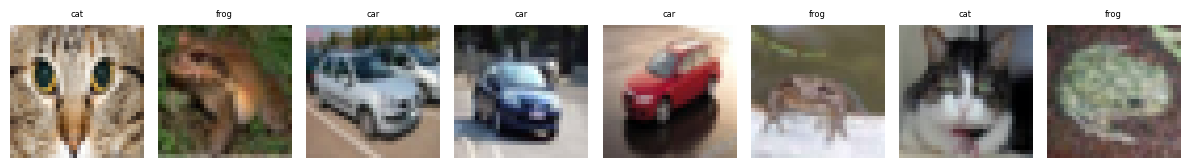

In [6]:
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

# without augmentation
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# with horizontal + vertical flip
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

full_base = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_base)
full_aug  = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_aug)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

n_total = len(full_base)        # 50000
n_train = int(0.8 * n_total)   # 40000
n_val   = n_total - n_train    # 10000

gen = torch.Generator().manual_seed(42)
train_base, val_base = random_split(full_base, [n_train, n_val], generator=gen)
train_aug,  val_aug  = random_split(full_aug,  [n_train, n_val], generator=torch.Generator().manual_seed(42))

def make_loaders(train_set, val_set):
    tr = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    vl = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    te = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return tr, vl, te

loaders = {
    'no_aug': make_loaders(train_base, val_base),
    'aug':    make_loaders(train_aug,  val_aug)
}

print(f'train={n_train}  val={n_val}  test={len(test_data)}')

imgs, labels = next(iter(loaders['no_aug'][0]))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    img = imgs[i].permute(1,2,0).numpy()
    img = img * np.array(std) + np.array(mean)
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Patch Embedding

In [7]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()
        self.num_patches = (img_size // patch_size) ** 2
        # use conv to split image into patches and project
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)           # (B, embed_dim, H/p, W/p)
        x = x.flatten(2)           # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)     # (B, num_patches, embed_dim)
        return x

### Vision Transformer

In [8]:
class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 embed_dim=128, num_heads=4, num_layers=4, num_classes=10):
        super(ViT, self).__init__()

        self.patch_embed  = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches       = (img_size // patch_size) ** 2

        # learnable CLS token
        self.cls_token    = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # learnable positional encoding
        self.pos_embed    = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer     = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm         = nn.LayerNorm(embed_dim)

        # classification head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_embed

        x   = self.transformer(x)
        x   = self.norm(x)
        # take CLS token output for classification
        out = self.head(x[:, 0])
        return out

### ResNet-18 Baseline

In [9]:
def get_resnet18():
    model = models.resnet18(weights=None)
    # adjust first conv for 32x32 input
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(512, NUM_CLASSES)
    return model

### Loss Functions - CE, Label Smoothing, Focal

In [10]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = nn.functional.cross_entropy(logits, targets, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

def get_criterion(loss_type):
    if loss_type == 'ce':
        return nn.CrossEntropyLoss()
    elif loss_type == 'label_smooth':
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    elif loss_type == 'focal':
        return FocalLoss(gamma=2.0)

### Optimizer Factory

In [11]:
def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=1e-3)
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)
    else:
        return optim.RMSprop(model.parameters(), lr=1e-3)

### Train and Eval Loops

In [12]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0
    with torch.no_grad():
        for x, y in loader:
            x, y  = x.to(DEVICE), y.to(DEVICE)
            out   = model(x)
            loss  = criterion(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total

### Main Experiment Runner

In [13]:
results       = {}
saved_models  = {}

def run_experiment(arch, loss_type, opt_name, aug_mode):
    name = f'{arch}_{loss_type}_{opt_name}_{aug_mode}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type,
        'optimizer': opt_name, 'augmentation': aug_mode, 'epochs': EPOCHS
    })

    train_loader, val_loader, test_loader = loaders[aug_mode]

    if arch == 'vit':
        model = ViT(
            img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3,
            embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
            num_layers=NUM_LAYERS, num_classes=NUM_CLASSES
        ).to(DEVICE)
    else:
        model = get_resnet18().to(DEVICE)

    criterion = get_criterion(loss_type)
    optimizer = get_optimizer(model, opt_name)

    best_val_acc = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), f'{name}_best.pt')

        wandb.log({
            'epoch': epoch,
            'train_loss': tr_loss, 'train_acc': tr_acc,
            'val_loss':   vl_loss, 'val_acc':   vl_acc
        })
        print(f'  epoch {epoch}/{EPOCHS}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')

    # load best checkpoint and test
    model.load_state_dict(torch.load(f'{name}_best.pt'))
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    print(f'  test_loss={te_loss:.4f}  test_acc={te_acc:.4f}')
    wandb.log({'test_loss': te_loss, 'test_acc': te_acc})

    results[name]      = {'test_acc': te_acc, 'test_loss': te_loss}
    saved_models[name] = model

    wandb.finish()
    return model

### Quick Test - run this first

In [14]:
run_experiment('vit',      'ce', 'adam', 'no_aug')
run_experiment('resnet18', 'ce', 'adam', 'no_aug')


starting: vit_ce_adam_no_aug


  epoch 1/4  train_loss=1.7823  train_acc=0.3288  val_loss=1.5435  val_acc=0.4274
  epoch 2/4  train_loss=1.4169  train_acc=0.4781  val_loss=1.2640  val_acc=0.5311
  epoch 3/4  train_loss=1.2108  train_acc=0.5570  val_loss=1.0955  val_acc=0.6021
  epoch 4/4  train_loss=1.0814  train_acc=0.6080  val_loss=1.0375  val_acc=0.6259
  test_loss=1.0595  test_acc=0.6208


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▅▇█
val_loss,█▄▂▁
epoch,4
test_acc,0.6208
test_loss,1.05948
train_acc,0.60805



starting: resnet18_ce_adam_no_aug


  epoch 1/4  train_loss=1.2708  train_acc=0.5348  val_loss=1.0691  val_acc=0.6186
  epoch 2/4  train_loss=0.7904  train_acc=0.7220  val_loss=0.9992  val_acc=0.6780
  epoch 3/4  train_loss=0.5821  train_acc=0.7952  val_loss=0.6954  val_acc=0.7581
  epoch 4/4  train_loss=0.4499  train_acc=0.8434  val_loss=0.6572  val_acc=0.7836
  test_loss=0.6798  test_acc=0.7773


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▄▇█
val_loss,█▇▂▁
epoch,4
test_acc,0.7773
test_loss,0.6798
train_acc,0.8434


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

### Full Grid - all combinations

In [15]:
for arch in MODELS:
    for aug in AUG_MODES:
        for lf in LOSS_FNS:
            for opt in OPTIMIZERS:
                run_experiment(arch, lf, opt, aug)


starting: vit_ce_adam_no_aug


  epoch 1/4  train_loss=1.7871  train_acc=0.3291  val_loss=1.6455  val_acc=0.4023
  epoch 2/4  train_loss=1.4535  train_acc=0.4674  val_loss=1.2617  val_acc=0.5421
  epoch 3/4  train_loss=1.2400  train_acc=0.5472  val_loss=1.1520  val_acc=0.5815
  epoch 4/4  train_loss=1.1195  train_acc=0.5965  val_loss=1.0777  val_acc=0.6183
  test_loss=1.0983  test_acc=0.6076


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▅▂▁
val_acc,▁▆▇█
val_loss,█▃▂▁
epoch,4
test_acc,0.6076
test_loss,1.09831
train_acc,0.5965



starting: vit_ce_sgd_no_aug


  epoch 1/4  train_loss=1.9178  train_acc=0.2868  val_loss=1.8060  val_acc=0.3351
  epoch 2/4  train_loss=1.6875  train_acc=0.3666  val_loss=1.6553  val_acc=0.3902
  epoch 3/4  train_loss=1.5582  train_acc=0.4230  val_loss=1.4957  val_acc=0.4477
  epoch 4/4  train_loss=1.4428  train_acc=0.4729  val_loss=1.3938  val_acc=0.4905
  test_loss=1.4026  test_acc=0.4935


...

  epoch 1/4  train_loss=1.1454  train_acc=0.3869  val_loss=0.9034  val_acc=0.4846
  epoch 2/4  train_loss=0.7900  train_acc=0.5414  val_loss=0.7816  val_acc=0.5334
  epoch 3/4  train_loss=0.6484  train_acc=0.6112  val_loss=0.7078  val_acc=0.5762
  epoch 4/4  train_loss=0.5499  train_acc=0.6596  val_loss=0.6274  val_acc=0.6204
  test_loss=0.6218  test_acc=0.6237


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▄▆█
val_loss,█▅▃▁
epoch,4
test_acc,0.6237
test_loss,0.62182
train_acc,0.65958



starting: resnet18_focal_rmsprop_aug


  epoch 1/4  train_loss=1.2332  train_acc=0.3562  val_loss=1.3242  val_acc=0.3692
  epoch 2/4  train_loss=0.8046  train_acc=0.5278  val_loss=0.9800  val_acc=0.5027
  epoch 3/4  train_loss=0.6366  train_acc=0.6070  val_loss=1.1541  val_acc=0.5229
  epoch 4/4  train_loss=0.5374  train_acc=0.6586  val_loss=0.6588  val_acc=0.5833
  test_loss=0.6855  test_acc=0.5771


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▅▆█
val_loss,█▄▆▁
epoch,4
test_acc,0.5771
test_loss,0.68554
train_acc,0.6586


### Results Summary

In [ ]:
print(f'{"config":<50} {"test_acc":>10} {"test_loss":>10}')
print('-' * 72)
for k, v in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    print(f'{k:<50} {v["test_acc"]:>10.4f} {v["test_loss"]:>10.4f}')

best = max(results, key=lambda x: results[x]['test_acc'])
print(f'\nbest: {best}  acc={results[best]["test_acc"]:.4f}')

config                                               test_acc  test_loss
------------------------------------------------------------------------
resnet18_label_smooth_adam_no_aug                      0.7816     1.0146
resnet18_ce_adam_no_aug                                0.7788     0.6669
resnet18_label_smooth_adam_aug                         0.7280     1.1130
resnet18_focal_adam_no_aug                             0.7262     0.4866
resnet18_ce_adam_aug                                   0.7255     0.7848
resnet18_ce_rmsprop_no_aug                             0.7195     0.8318
resnet18_focal_rmsprop_no_aug                          0.7148     0.4655
resnet18_label_smooth_sgd_no_aug                       0.7089     1.1845
resnet18_ce_sgd_no_aug                                 0.7059     0.8794
resnet18_focal_adam_aug                                0.6758     0.5083
resnet18_label_smooth_rmsprop_no_aug                   0.6691     1.2792
resnet18_ce_sgd_aug                                

### Upload to HuggingFace

In [16]:
create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in saved_models.keys():
    fname = f'{name}_best.pt'
    if os.path.exists(fname):
        api.upload_file(
            path_or_fileobj=fname,
            path_in_repo=f'models/{fname}',
            repo_id=HF_REPO
        )
        print(f'uploaded: {fname}')

print(f'https://huggingface.co/{HF_REPO}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  vit_ce_adam_no_aug_best.pt  :  17%|#6        |  561kB / 3.40MB            

uploaded: vit_ce_adam_no_aug_best.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

uploaded: resnet18_focal_sgd_aug_best.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...focal_rmsprop_aug_best.pt:   9%|8         | 3.91MB / 44.8MB            

uploaded: resnet18_focal_rmsprop_aug_best.pt
https://huggingface.co/MAKSWE/exp10-vit-resnet


In [17]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')

W&B : https://wandb.ai/ayanmdkhan2340-delhi-technological-university/exp10-vit-resnet
HF  : https://huggingface.co/MAKSWE/exp10-vit-resnet
